# 08 - Exploración: filtrar NDVI a píxeles agrícolas

**Objetivo:** ver si el NDVI mejora como predictor cuando se excluyen las áreas no agrícolas (ciudades, montes, cuerpos de agua) del promedio por partido.

**Herramienta:** Dynamic World de Google, disponible en GEE desde 2015, con resolución de 10 metros. Clasifica cada píxel en 9 clases, incluyendo "crops" (cultivos). No distingue soja de maíz, pero sí separa cultivos de todo lo demás.

**Enfoque:** para cada partido y fecha de NDVI, calcular dos promedios: el actual (todos los píxeles) y el filtrado (solo píxeles clasificados como cultivo). Si hay diferencia significativa, vale la pena seguir con el mapa del INTA que sí distingue soja.

**Nota:** Dynamic World usa Sentinel-2 (disponible desde 2015). Para campañas anteriores a 2015 no hay máscara, por lo que esta exploración solo cubre las campañas más recientes.

---
## Autenticación y configuración

In [1]:
import ee
ee.Authenticate()

True

In [2]:
ee.Initialize(project='rinde-soja')
print('Earth Engine listo!')

*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


Earth Engine listo!


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT = Path.home() / "Documents" / "rinde-soja"

# Polígonos de los 5 partidos (mismo filtro que el notebook 02)
PARTIDOS_GAUL = ["General Arenales", "Leandro N. Alem", "Junin", "Lincoln", "General Pinto"]
NOMBRE_MAP = {"Junin": "Junín"}

partidos_fc = (ee.FeatureCollection("FAO/GAUL/2015/level2")
               .filter(ee.Filter.eq("ADM0_NAME", "Argentina"))
               .filter(ee.Filter.eq("ADM1_NAME", "Buenos Aires"))
               .filter(ee.Filter.inList("ADM2_NAME", PARTIDOS_GAUL)))

n = partidos_fc.size().getInfo()
assert n == 5, f"Se esperaban 5 polígonos, se encontraron {n}"
print(f"Polígonos OK: {sorted(partidos_fc.aggregate_array('ADM2_NAME').getInfo())}")

C:\Users\agust\AppData\Roaming\Python\Python312\site-packages\ee\deprecation.py:215: DeprecationWarning: 

Attention required for FAO/GAUL/2015/level2! You are using a deprecated asset.
To make sure your code keeps working, please update it.
This dataset has been superseded by FAO/GAUL/2025/level2

Learn more: https://developers.google.com/earth-engine/datasets/catalog/FAO_GAUL_2015_level2

  warnings.warn(warning, category=DeprecationWarning)


Polígonos OK: ['General Arenales', 'General Pinto', 'Junin', 'Leandro N. Alem', 'Lincoln']


---
## ¿Qué proporción de cada partido es agrícola?

Antes de filtrar el NDVI, veo cuánta superficie de cada partido es cultivo según Dynamic World. Si un partido es 95% agrícola, filtrar no va a cambiar mucho. Si tiene 60%, la diferencia puede ser grande.

In [4]:
# Clase 4 = "crops" en Dynamic World
dw = (ee.ImageCollection('GOOGLE/DYNAMICWORLD/V1')
      .filterDate('2023-10-01', '2024-03-31')
      .filterBounds(partidos_fc))

print(f"Imágenes Dynamic World disponibles (oct 2023 - mar 2024): {dw.size().getInfo()}")

# Para cada píxel, la clase más frecuente durante el verano
dw_mode = dw.select('label').mode()

# Máscara binaria: 1 = cultivo, 0 = no cultivo
crop_mask = dw_mode.eq(4)  # 4 = crops en Dynamic World

# Fracción agrícola por partido
fraccion = crop_mask.reduceRegions(
    collection=partidos_fc,
    reducer=ee.Reducer.mean(),
    scale=10
).getInfo()

print("\nFracción agrícola por partido (verano 2023/24):")
print("=" * 50)
for f in fraccion['features']:
    nombre = f['properties']['ADM2_NAME']
    nombre = NOMBRE_MAP.get(nombre, nombre)
    frac = f['properties'].get('mean', 0)
    print(f"  {nombre:22s} | {frac*100:.1f}% cultivos")

Imágenes Dynamic World disponibles (oct 2023 - mar 2024): 219

Fracción agrícola por partido (verano 2023/24):
  General Arenales       | 86.1% cultivos
  General Pinto          | 63.6% cultivos
  Junín                  | 75.3% cultivos
  Leandro N. Alem        | 79.2% cultivos
  Lincoln                | 56.5% cultivos


---
## Comparar NDVI con y sin máscara para una campaña

Tomo la campaña 2023/24 como ejemplo. Para cada fecha de NDVI MODIS calculo el promedio de dos formas:
1. **Sin filtro:** todos los píxeles del partido (lo que hacemos hoy)
2. **Con filtro:** solo los píxeles clasificados como cultivo por Dynamic World

La diferencia entre ambos muestra cuánto ruido introducen las áreas no agrícolas.

In [6]:
# MODIS NDVI para la campaña 2023/24
modis = (ee.ImageCollection('MODIS/061/MOD13Q1')
         .filterDate('2023-10-01', '2024-04-30')
         .select('NDVI'))

# Máscara de cultivos: probabilidad promedio de "crops" durante el verano
crop_prob = (ee.ImageCollection('GOOGLE/DYNAMICWORLD/V1')
             .filterDate('2023-10-01', '2024-03-31')
             .filterBounds(partidos_fc)
             .select('crops')
             .mean())

crop_mask = crop_prob.gt(0.5)

print("Extrayendo NDVI con y sin máscara de cultivos (campaña 2023/24)...")
print("Esto tarda unos 2-3 minutos...")

registros = []
img_list = modis.toList(modis.size()).getInfo()

for img_info in img_list:
    img_id = img_info['id']
    image = ee.Image(img_id).select('NDVI').multiply(0.0001)
    fecha = ee.Image(img_id).date().format('YYYY-MM-dd').getInfo()
    
    # Sin filtro
    sin = image.reduceRegions(
        collection=partidos_fc,
        reducer=ee.Reducer.mean(),
        scale=250
    ).getInfo()
    
    # Con filtro: enmascarar píxeles no agrícolas
    image_masked = image.updateMask(crop_mask)
    
    con = image_masked.reduceRegions(
        collection=partidos_fc,
        reducer=ee.Reducer.mean(),
        scale=250
    ).getInfo()
    
    for fs, fc in zip(sin['features'], con['features']):
        nombre = fs['properties']['ADM2_NAME']
        nombre = NOMBRE_MAP.get(nombre, nombre)
        registros.append({
            'fecha': fecha,
            'partido': nombre,
            'ndvi_sin_filtro': fs['properties'].get('mean'),
            'ndvi_con_filtro': fc['properties'].get('mean'),
        })
    print(f"  {fecha} OK")

df_comp = pd.DataFrame(registros)
df_comp['fecha'] = pd.to_datetime(df_comp['fecha'])
df_comp['diferencia'] = df_comp['ndvi_con_filtro'] - df_comp['ndvi_sin_filtro']
print(f"\nListo: {len(df_comp)} registros")

Extrayendo NDVI con y sin máscara de cultivos (campaña 2023/24)...
Esto tarda unos 2-3 minutos...
  2023-10-16 OK
  2023-11-01 OK
  2023-11-17 OK
  2023-12-03 OK
  2023-12-19 OK
  2024-01-01 OK
  2024-01-17 OK
  2024-02-02 OK
  2024-02-18 OK
  2024-03-05 OK
  2024-03-21 OK
  2024-04-06 OK
  2024-04-22 OK

Listo: 65 registros


---
## Visualizar la diferencia

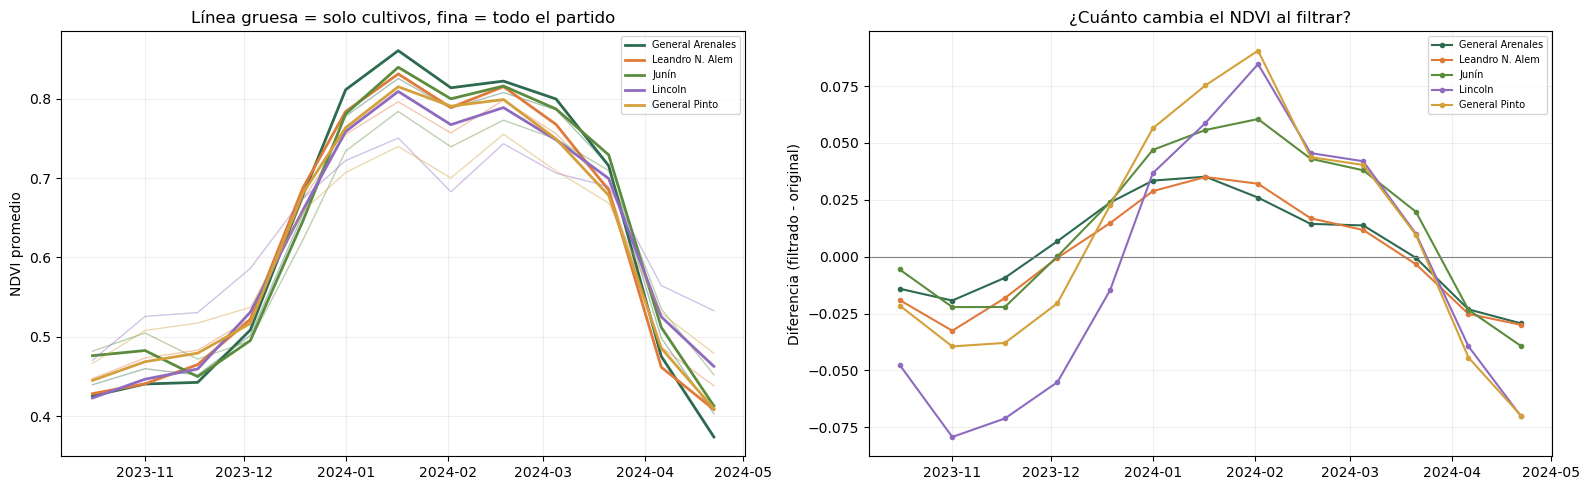


Diferencia promedio por partido (NDVI filtrado - NDVI original):
  General Arenales       | +0.0044 (+0.7%)
  Leandro N. Alem        | +0.0008 (+0.1%)
  Junín                  | +0.0135 (+2.2%)
  Lincoln                | -0.0077 (-1.2%)
  General Pinto          | +0.0081 (+1.3%)


In [7]:
COLOR_PARTIDOS = {
    "General Arenales": "#2D6A4F",
    "Leandro N. Alem":  "#E07A3A",
    "Junín":            "#5B8C3E",
    "Lincoln":          "#8E6BBF",
    "General Pinto":    "#D4A03C",
}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Panel 1: NDVI con y sin filtro, superpuestos
ax = axes[0]
for partido in COLOR_PARTIDOS:
    dp = df_comp[df_comp.partido == partido].sort_values('fecha')
    ax.plot(dp.fecha, dp.ndvi_sin_filtro, color=COLOR_PARTIDOS[partido], linewidth=1, alpha=0.4)
    ax.plot(dp.fecha, dp.ndvi_con_filtro, color=COLOR_PARTIDOS[partido], linewidth=2, label=partido)

ax.set_ylabel('NDVI promedio')
ax.set_title('Línea gruesa = solo cultivos, fina = todo el partido')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.2)

# Panel 2: diferencia (filtrado - sin filtrar) por partido
ax = axes[1]
for partido in COLOR_PARTIDOS:
    dp = df_comp[df_comp.partido == partido].sort_values('fecha')
    ax.plot(dp.fecha, dp.diferencia, color=COLOR_PARTIDOS[partido], linewidth=1.5, marker='o', markersize=3, label=partido)

ax.axhline(y=0, color='gray', linewidth=0.8)
ax.set_ylabel('Diferencia (filtrado - original)')
ax.set_title('¿Cuánto cambia el NDVI al filtrar?')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

# Resumen numérico
print("\nDiferencia promedio por partido (NDVI filtrado - NDVI original):")
print("=" * 55)
for partido in COLOR_PARTIDOS:
    dp = df_comp[df_comp.partido == partido]
    diff = dp.diferencia.mean()
    print(f"  {partido:22s} | {diff:+.4f} ({'+' if diff>0 else ''}{diff/dp.ndvi_sin_filtro.mean()*100:.1f}%)")

### Resultado

La diferencia promedio es chica (+0,1% a +2,2%), pero eso esconde lo importante: el efecto cambia de signo a lo largo de la campaña. Al inicio (octubre-noviembre) el NDVI filtrado es menor porque la soja recién se sembró y las pasturas y montes ya están verdes. En el pico (enero-febrero) el filtrado es mayor, hasta +0,09 en Lincoln y General Pinto, porque la soja en pleno desarrollo supera al promedio diluido del partido. Es decir, el filtro no solo cambia el nivel del NDVI sino la forma de la curva, que es lo que capturan las variables más importantes del modelo (máximo, pendiente, variabilidad).

El efecto es mayor en los partidos menos agrícolas (Lincoln 56%, General Pinto 64%) y menor en los más agrícolas (General Arenales 86%), lo cual es coherente. Esto confirma que filtrar a superficie cultivada mejora la señal, pero para que el impacto sea completo haría falta distinguir soja de maíz, lo cual requiere el Mapa Nacional de Cultivos del INTA.